In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/muhammadbinimran/housing-price-prediction-data/housing_price_dataset.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/muhammadbinimran/housing-price-prediction-data/housing_price_dataset.csv")
df.head(10)

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065
5,2095,2,3,Suburb,2020,198208.803907
6,2724,2,1,Suburb,1993,343429.319110
7,2044,4,3,Rural,1957,184992.321268
8,2638,4,3,Urban,1959,377998.588152
9,1121,5,2,Urban,2004,95961.926014


In [3]:
def wrangle(filepath):
    df = pd.read_csv(filepath)

    # Remove extreme outliers (10th–90th percentile)
    low, high = df["SquareFeet"].quantile([0.1, 0.9])
    mask_area = df["SquareFeet"].between(low, high)
    df = df[mask_area]

    # Remove impossible values
    df = df[
        (df["SquareFeet"] > 0) &
        (df["Bedrooms"] > 0) &
        (df["Bathrooms"] > 0) &
        (df["YearBuilt"] > 1800)
    ]

    # Clean missing values
    df = df.copy()
    df = df.dropna()

    return df


In [4]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3+ MB


In [6]:
df.describe()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2006.374680,3.498700,1.995420,1985.404420,224827.325151
std,575.513241,1.116326,0.815851,20.719377,76141.842966
min,1000.000000,2.000000,1.000000,1950.000000,-36588.165397
25%,1513.000000,3.000000,1.000000,1967.000000,169955.860225
50%,2007.000000,3.000000,2.000000,1985.000000,225052.141166
75%,2506.000000,4.000000,3.000000,2003.000000,279373.630052
max,2999.000000,5.000000,3.000000,2021.000000,492195.259972


In [7]:
corr_value = float(df['Price'].corr(df['SquareFeet']))
corr_value


0.7507197856708844

In [8]:
df.isnull().sum()


SquareFeet      0
Bedrooms        0
Bathrooms       0
Neighborhood    0
YearBuilt       0
Price           0
dtype: int64

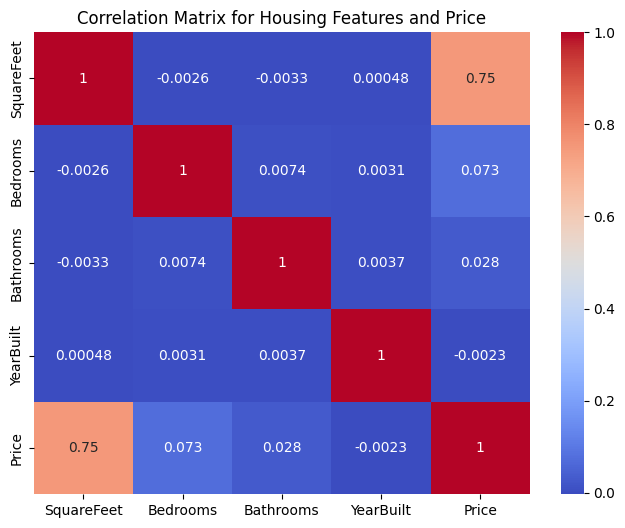

In [9]:
corr = df[['SquareFeet', 'Bedrooms', 'Bathrooms', 'YearBuilt', 'Price']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix for Housing Features and Price")
plt.show()


In [10]:
corr = df.corr(numeric_only=True)["Price"].sort_values(ascending=False)
print(corr)

Price         1.000000
SquareFeet    0.750720
Bedrooms      0.072624
Bathrooms     0.028418
YearBuilt    -0.002288
Name: Price, dtype: float64


In [11]:
low, high = df["SquareFeet"].quantile([0.1, 0.9])
mask_area = df["SquareFeet"].between(low, high)
df = df[mask_area]


Text(0.5, 1.0, 'Distribution of Apartment Prices')

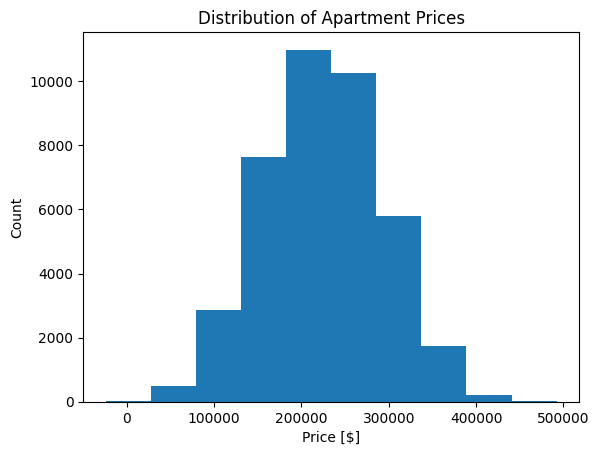

In [12]:
fig, ax = plt.subplots()

# Plot the histogram on the axes object
ax.hist(df["Price"])

# Label axes using the axes 
ax.set_xlabel("Price [$]")
ax.set_ylabel("Count")


# Add title 
ax.set_title("Distribution of Apartment Prices")

Text(0.5, 1.0, 'Distribution of Apartment Prices')

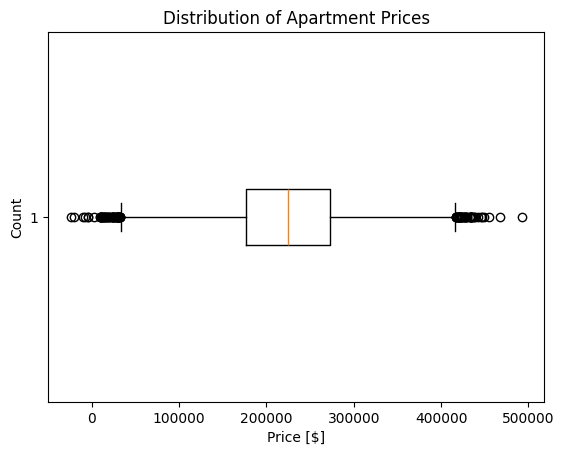

In [13]:
fig, ax = plt.subplots()

# Plot the histogram on the axes object
ax.boxplot(df["Price"] , vert= False)

# Label axes using the axes 
ax.set_xlabel("Price [$]")
ax.set_ylabel("Count")


# Add title 
ax.set_title("Distribution of Apartment Prices")

Text(0.5, 1.0, 'Melbourne: Price vs. Area')

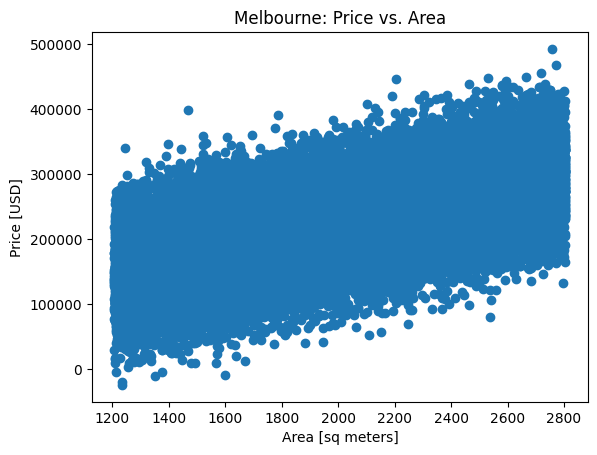

In [14]:
fig, ax = plt.subplots() 

# Create the scatter plot on the axes object
ax.scatter(df["SquareFeet"],df["Price"]) 

# Label axes 
ax.set_ylabel("Price [USD]")
ax.set_xlabel("Area [sq meters]")

#  Add title 
ax.set_title("Melbourne: Price vs. Area")

Text(0.5, 1.0, 'Melbourne: year vs. price')

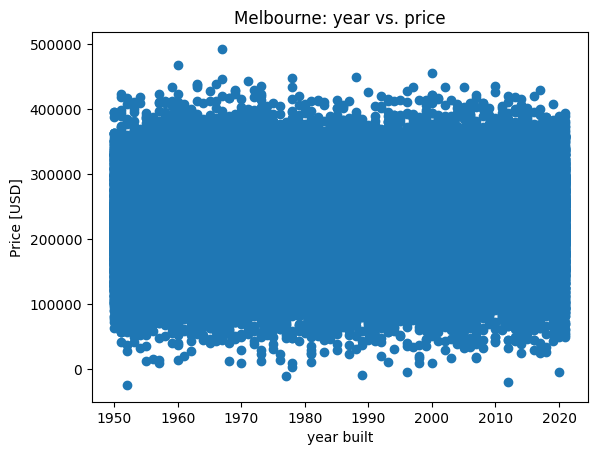

In [15]:
fig, ax = plt.subplots() 

# Create the scatter plot on the axes object
ax.scatter(df["YearBuilt"],df["Price"]) 

# Label axes 
ax.set_ylabel("Price [USD]")
ax.set_xlabel("year built")

#  Add title 
ax.set_title("Melbourne: year vs. price")

In [16]:
X = df[['SquareFeet']]
y = df['Price']

In [17]:
X = df[['SquareFeet']]
y = df['Price']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [18]:
# Baseline model using the mean of y_train
y_mean = float(y_train.mean())

# Predict the mean for every training sample
y_pred_baseline = [y_mean] * len(y_train)

# Print the baseline prediction value
print("Baseline prediction (mean of y_train):", y_mean)


Baseline prediction (mean of y_train): 224799.52688304917


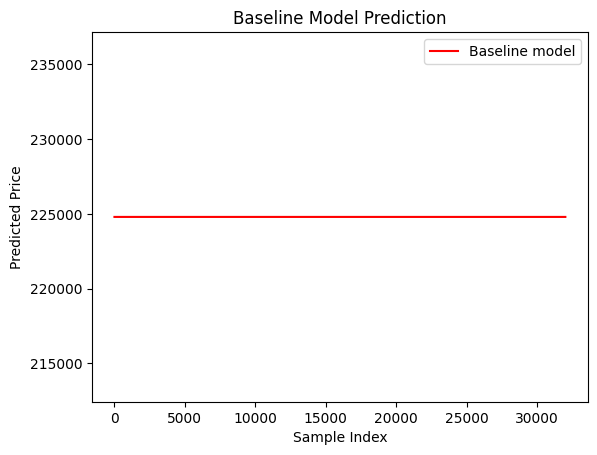

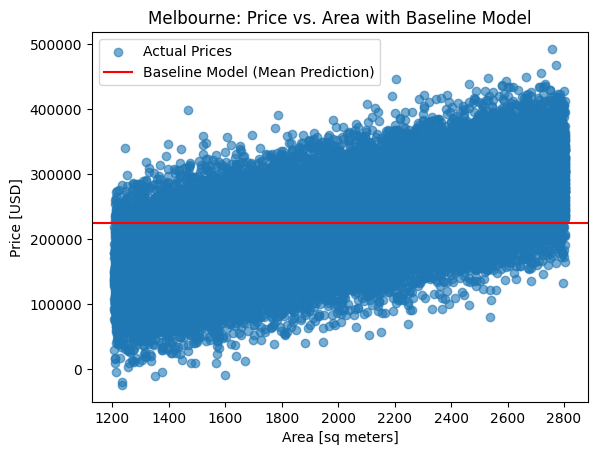

In [19]:
plt.plot(y_pred_baseline, color="red", label="Baseline model")
plt.title("Baseline Model Prediction")
plt.xlabel("Sample Index")
plt.ylabel("Predicted Price")
plt.legend()
plt.show()
fig, ax = plt.subplots()

# Scatter plot: Price vs Area
ax.scatter(df["SquareFeet"], df["Price"], alpha=0.6, label="Actual Prices")

# Baseline line (horizontal)
ax.axhline(y=y_mean, color="red", label="Baseline Model (Mean Prediction)")

# Labels and title
ax.set_ylabel("Price [USD]")
ax.set_xlabel("Area [sq meters]")
ax.set_title("Melbourne: Price vs. Area with Baseline Model")

ax.legend()
plt.show()


In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [22]:
model.fit(X_train, y_train)

LinearRegression()

In [23]:
y_pred = model.predict(X_test)
y_pred

array([202510.6289223 , 211188.28978991, 208993.93876592, ...,
       270136.53775268, 160020.01363949, 211188.28978991])

In [24]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 40486.037139646294
R2: 0.4441857158885014


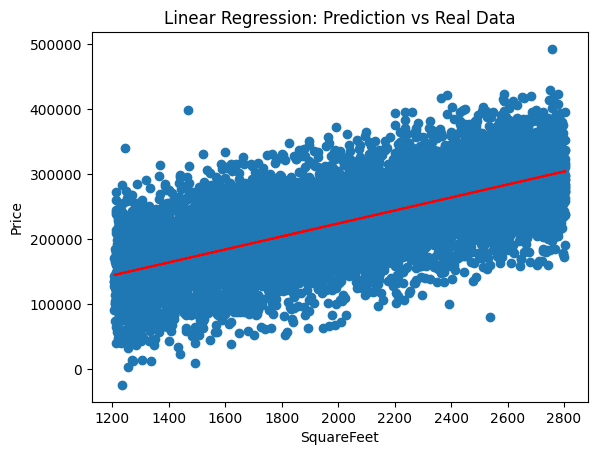

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred, color="red")
plt.xlabel("SquareFeet")
plt.ylabel("Price")
plt.title("Linear Regression: Prediction vs Real Data")
plt.show()

In [26]:
coefficient = round(model.coef_[0], 2)
print("Model coefficient:", coefficient)


Model coefficient: 99.74


In [27]:
intercept = round(model.intercept_, 2)
print("Model intercept:", intercept)


Model intercept: 24468.97


In [28]:
print(f" price = {intercept} + {coefficient}*SquareFeet")

 price = 24468.97 + 99.74*SquareFeet


In [29]:
def predict_price():
    sqft = float(input("Enter SquareFeet: "))
    price = intercept + coefficient * sqft
    print(f"Predicted price: {round(price, 2)}")

predict_price()


StdinNotImplementedError: raw_input was called, but this frontend does not support input requests.

In [ ]:
X = df.select_dtypes(include='number').drop(columns=['Price'])
y = df["Price"]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Predict on training and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Compute metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

# Communicate results
print("Decision Tree Performance")
print("-------------------------")
print(f"Train MAE:  {train_mae:.2f}")
print(f"Test MAE:   {test_mae:.2f}")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE:  {test_rmse:.2f}")


In [ ]:
X = df.select_dtypes(include='number').drop(columns=['Price'])
y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.tree import DecisionTreeRegressor

model_Dt= DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

model_Dt.fit(X_train, y_train)

In [ ]:
y_predDt = model_Dt.predict(X_test)
y_predDt

In [ ]:

print("Decision Tree Regressor")
print("MAE:", mean_absolute_error(y_test,y_predDt))
print("R2:", r2_score(y_test, y_predDt))

In [ ]:

plt.figure()
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Decision Tree)")
plt.show()


In [ ]:
X = df.select_dtypes(include='number').drop(columns=['Price'])
y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

modelrf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

modelrf.fit(X_train, y_train)


In [ ]:
y_predrf = modelrf.predict(X_test)
y_predrf

In [ ]:

print("Random Forest Regressor")
print("MAE:", mean_absolute_error(y_test,y_predrf))
print("R2:", r2_score(y_test, y_predrf))

In [ ]:
X = df[["SquareFeet"]]
y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
modelpl = LinearRegression()
modelpl.fit(X_train_poly, y_train)
y_pred = modelpl.predict(X_test_poly)

In [ ]:
print("Polynomial Regression (degree=2)")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))


In [ ]:
X = df.select_dtypes(include='number').drop(columns=['Price'])
y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

gbr.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = gbr.predict(X_test)

print("Gradient Boosting Regressor")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))